## Setup
First, we need to install the required libraries: MONAI (with all its dependencies like `pydicom` and `nibabel`), `tqdm` for progress bars, and `matplotlib` for plotting.

In [1]:
!pip install -q "monai[all]" "tqdm" "matplotlib"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/

Next, we'll import the necessary modules from `monai`, `pydicom`, `nibabel`, `matplotlib`, and `numpy`.

In [2]:
import os
import tempfile
import matplotlib.pyplot as plt
import numpy as np

import pydicom
import nibabel as nib

from monai.transforms import LoadImage, Orientation, ScaleIntensityRange, Resize, Compose
from monai.data import decollate_batch
from monai.visualize import plot_2d_or_3d_image
from monai.utils import first

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


## Download Sample NIfTI Dataset
We'll download a small brain MRI dataset (BraTS 2018) from MONAI's public resources to use as real NIfTI data. This involves using `gdown` to download a zipped file and then extracting its contents.

In [3]:
from monai.apps import download_and_extract
import os
import shutil
import tempfile # Import tempfile for creating temporary directory

# Define data_dir at the beginning of the cell
data_dir = tempfile.mkdtemp()

# Define the resource URL for Task09_Spleen.tar
resource = "https://msd-for-monai.s3-us-west-2.amazonaws.com/Task09_Spleen.tar"

# Ensure clean extraction by removing existing directory if it exists
extracted_target_dir = os.path.join(data_dir, "Task09_Spleen")
if os.path.exists(extracted_target_dir):
    print(f"Removing existing directory: {extracted_target_dir}")
    shutil.rmtree(extracted_target_dir)

print(f"Downloading and extracting Task09_Spleen dataset to: {data_dir}")
# download_and_extract handles creation of subdirectories
# It will extract to data_dir/Task09_Spleen/
download_and_extract(resource, output_dir=data_dir, file_type="tar")
print("Dataset downloaded and extracted.")

# --- Debugging: Inspect extracted contents ---
print(f"Contents of {data_dir}: {os.listdir(data_dir)}")

# After extraction, Task09_Spleen should exist
if os.path.exists(extracted_target_dir):
    print(f"Contents of {extracted_target_dir}: {os.listdir(extracted_target_dir)}")
    images_tr_dir = os.path.join(extracted_target_dir, "imagesTr")
    if os.path.exists(images_tr_dir):
        # Filter out AppleDouble files (starting with '._')
        actual_nifti_files = [f for f in os.listdir(images_tr_dir) if f.endswith('.nii.gz') and not f.startswith('._')]
        if actual_nifti_files:
            print(f"Actual NIfTI files found in {images_tr_dir}: {actual_nifti_files[:5]}...")
            # Pick the first actual NIfTI file found
            real_nifti_filepath = os.path.join(images_tr_dir, actual_nifti_files[0])

            # Update nifti_filepath to point to a real image from the downloaded dataset
            global nifti_filepath
            nifti_filepath = real_nifti_filepath
            print(f"Updated NIfTI filepath to real data: {nifti_filepath}")
        else:
            print(f"No .nii.gz files found in {images_tr_dir} after filtering. Keeping dummy NIfTI filepath.")
            real_nifti_filepath = None # Indicate it wasn't found
    else:
        print(f"Directory {images_tr_dir} does not exist. Keeping dummy NIfTI filepath.")
        real_nifti_filepath = None
else:
    print(f"Directory {extracted_target_dir} does not exist after download. Keeping dummy NIfTI filepath.")
    real_nifti_filepath = None

# If real_nifti_filepath was not updated, keep the dummy one
if real_nifti_filepath is None:
    print("Keeping the dummy NIfTI filepath for now.")

Task09_Spleen.tar: 1.50GB [01:58, 13.6MB/s]                            

2026-05-30 05:49:12,439 - INFO - Downloaded: /tmp/tmp7110u7k8/Task09_Spleen.tar
2026-05-30 05:49:12,440 - INFO - Expected md5 is None, skip md5 check for file /tmp/tmp7110u7k8/Task09_Spleen.tar.
2026-05-30 05:49:12,442 - INFO - Writing into directory: /tmp/tmposo76n38.


Dataset downloaded and extracted.
Contents of /tmp/tmposo76n38: ['._Task09_Spleen', 'Task09_Spleen']
Contents of /tmp/tmposo76n38/Task09_Spleen: ['._imagesTs', '._dataset.json', 'labelsTr', 'imagesTs', '._imagesTr', 'imagesTr', 'dataset.json', '._labelsTr']
Actual NIfTI files found in /tmp/tmposo76n38/Task09_Spleen/imagesTr: ['spleen_19.nii.gz', 'spleen_31.nii.gz', 'spleen_24.nii.gz', 'spleen_61.nii.gz', 'spleen_47.nii.gz']...
Updated NIfTI filepath to real data: /tmp/tmposo76n38/Task09_Spleen/imagesTr/spleen_19.nii.gz


## NIfTI File Visualization
We'll use MONAI's `LoadImage` to load the NIfTI file and then `matplotlib` and `plot_2d_or_3d_image` for visualization.

NIfTI image shape: torch.Size([512, 512, 51])


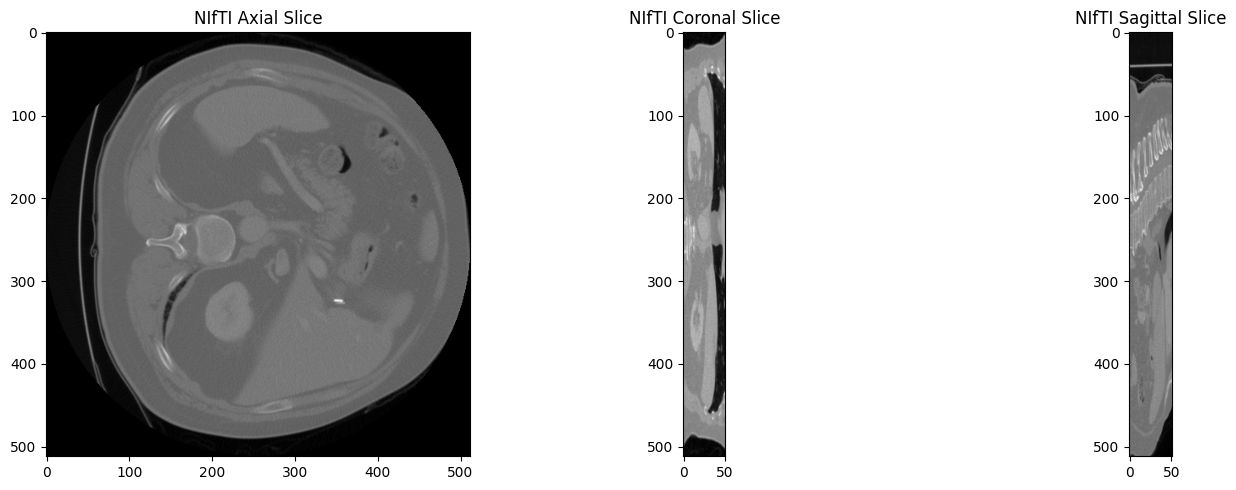

In [4]:
# Load NIfTI file
nifti_loader = LoadImage(image_only=True)
nifti_image = nifti_loader(nifti_filepath)
print(f"NIfTI image shape: {nifti_image.shape}")

# Visualize NIfTI image (middle slice) using matplotlib for axial, coronal, and sagittal views
plt.figure("NIfTI Visualization", (15, 5))
plt.subplot(1, 3, 1)
plt.title("NIfTI Axial Slice")
plt.imshow(nifti_image[..., nifti_image.shape[-1] // 2], cmap="gray")
plt.subplot(1, 3, 2)
plt.title("NIfTI Coronal Slice")
plt.imshow(nifti_image[:, nifti_image.shape[1] // 2, :], cmap="gray")
plt.subplot(1, 3, 3)
plt.title("NIfTI Sagittal Slice")
plt.imshow(nifti_image[nifti_image.shape[0] // 2, :, :], cmap="gray")
plt.tight_layout()
plt.show()

### 1. Segmentation Dataset Preparation
We will configure the data dictionaries and the necessary transforms for training.

In [5]:
from monai.transforms import (LoadImaged, EnsureChannelFirstd, Spacingd, Orientationd, ScaleIntensityRanged, CropForegroundd, RandCropByPosNegLabeld, RandFlipd, DivisiblePadd, Compose)
from monai.data import CacheDataset, DataLoader
import glob
from monai.utils import first
import os
import tempfile

# Fix: Search for the directory where the dataset was extracted
# We check common temporary locations if data_dir is missing
try:
    # If data_dir exists in globals, use it, otherwise find it in /tmp
    if 'data_dir' not in globals():
        base_temp = tempfile.gettempdir()
        candidates = [os.path.join(base_temp, d) for d in os.listdir(base_temp) if "tmp" in d and os.path.isdir(os.path.join(base_temp, d, "Task09_Spleen"))]
        data_dir = candidates[0] if candidates else base_temp
except:
    data_dir = tempfile.gettempdir()

extracted_target_dir = os.path.join(data_dir, "Task09_Spleen")
images_tr_dir = os.path.join(extracted_target_dir, "imagesTr")
labels_tr_dir = os.path.join(extracted_target_dir, "labelsTr")

# Get paths
train_images = sorted(glob.glob(os.path.join(images_tr_dir, "*.nii.gz")))
train_labels = sorted(glob.glob(os.path.join(labels_tr_dir, "*.nii.gz")))
data_dicts = [{"image": image, "label": label} for image, label in zip(train_images, train_labels)]

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys=["image"], a_min=-57, a_max=164, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 96),
        pos=1, neg=1, num_samples=2,
        image_key="image", image_threshold=0,
    ),
    RandFlipd(keys=["image", "label"], spatial_axis=[0], prob=0.5),
    DivisiblePadd(keys=["image", "label"], k=16),
])

# CacheDataset stores processed data in RAM
train_ds = CacheDataset(data=data_dicts, transform=train_transforms, cache_rate=1.0, num_workers=4)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)

check_data = first(train_loader)
print(f"Batch Image shape: {check_data['image'].shape}")

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
Loading dataset: 100%|██████████| 41/41 [02:06<00:00,  3.09s/it]


Batch Image shape: torch.Size([8, 1, 96, 96, 96])


### 2. Image and Mask Visualization
We will verify that the segmentation mask matches the spleen's anatomy in the original image.

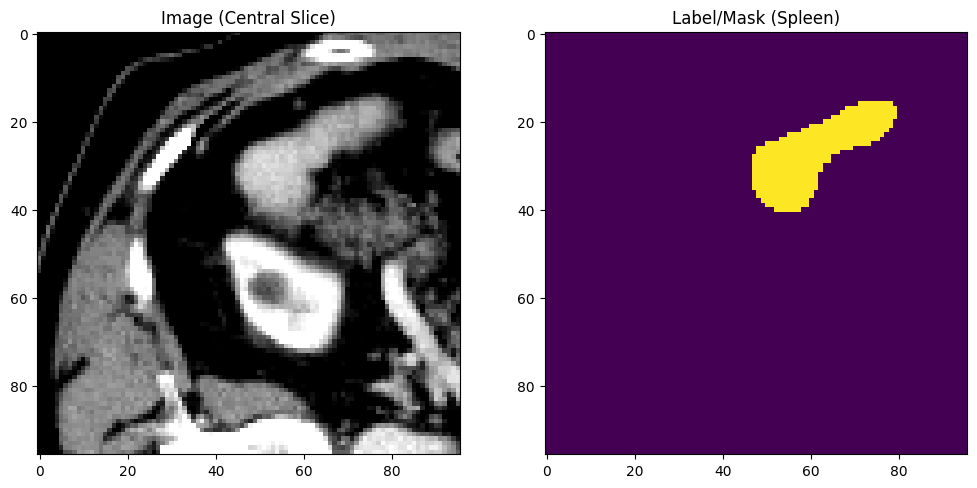

In [6]:
# Extract a sample from the check_data batch
# check_data['image'] has shape [Batch, Channel, H, W, D]
image = check_data["image"][0, 0]
label = check_data["label"][0, 0]

plt.figure("check", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Image (Central Slice)")
plt.imshow(image[:, :, image.shape[2] // 2], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Label/Mask (Spleen)")
plt.imshow(label[:, :, label.shape[2] // 2])
plt.show()

### 3. Define Model, Loss, and Optimizer
We will use a standard UNet architecture from MONAI, optimized for 3D segmentation, along with Dice Loss.

In [7]:
import torch
from monai.networks.nets import UNet
from monai.losses import DiceLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the UNet architecture
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2, # Spleen and Background
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

# Define Loss function and Optimizer
loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4)

print(f"Model initialized on device: {device}")

Model initialized on device: cuda


### 4. Training Loop
We will run a short training process to demonstrate how the model learns to segment the spleen.

Starting training for 100 epochs...


Epoch 1/100: 100%|██████████| 11/11 [00:09<00:00,  1.18it/s, loss=0.32]


Average Loss: 0.2732


Epoch 2/100: 100%|██████████| 11/11 [00:09<00:00,  1.19it/s, loss=0.283]


Average Loss: 0.2620


...

Average Loss: 0.2430


Epoch 99/100: 100%|██████████| 11/11 [00:08<00:00,  1.23it/s, loss=0.504]


Average Loss: 0.2887


Epoch 100/100: 100%|██████████| 11/11 [00:09<00:00,  1.19it/s, loss=0.286]

Average Loss: 0.1946


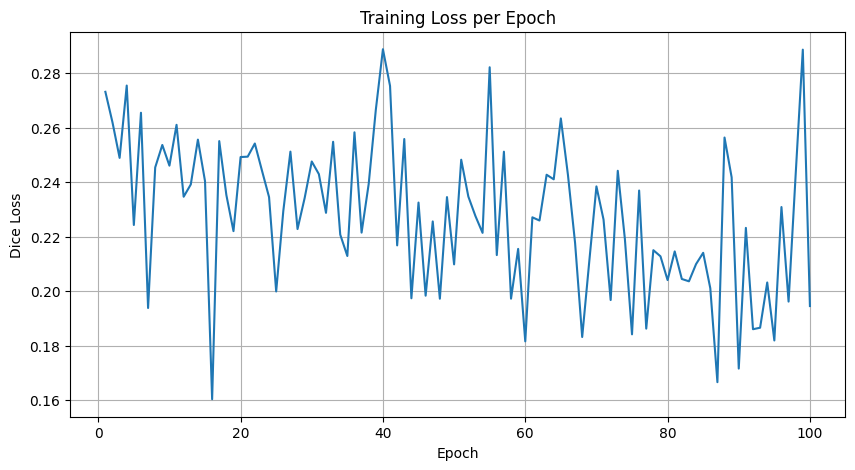

In [11]:
# from tqdm import tqdm

# max_epochs = 100
# epoch_loss_values = []

# print(f"Starting training for {max_epochs} epochs...")

# for epoch in range(max_epochs):
#     model.train()
#     epoch_loss = 0
#     step = 0

#     # Added progress bar to the batch loop
#     progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{max_epochs}")

#     for batch_data in progress_bar:
#         step += 1
#         inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)

#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = loss_function(outputs, labels)
#         loss.backward()
#         optimizer.step()

#         epoch_loss += loss.item()
#         progress_bar.set_postfix({"loss": loss.item()})

#     epoch_loss /= step
#     epoch_loss_values.append(epoch_loss)
#     print(f"Average Loss: {epoch_loss:.4f}")

# # Plot the training loss
# plt.figure(figsize=(10, 5))
# plt.title("Training Loss per Epoch")
# plt.plot(range(1, max_epochs + 1), epoch_loss_values)
# plt.xlabel("Epoch")
# plt.ylabel("Dice Loss")
# plt.grid(True)
# plt.show()

### 5. Advanced Training: Early Stopping and LR Scheduling
To handle the plateau you observed, we can use `torch.optim.lr_scheduler` and a custom EarlyStopping class.

In [13]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Initialize scheduler (removed deprecated 'verbose' argument)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)

# Simple Early Stopping logic
max_epochs = 300
patience = 15
counter = 0
best_loss = float('inf')

print("Re-starting training with Scheduler and Early Stopping...")

# Note: This is a continuation. If you want to start fresh, re-run the Model/Optimizer cell.
for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0
    for batch_data in train_loader:
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    scheduler.step(avg_loss)

    if avg_loss < best_loss:
        best_loss = avg_loss
        counter = 0
        torch.save(model.state_dict(), "best_metric_model.pth")
        print(f"Epoch {epoch+1}: loss improved to {best_loss:.4f}")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

print(f"Training finished. Best Loss: {best_loss:.4f}")

Re-starting training with Scheduler and Early Stopping...
Epoch 1: loss improved to 0.2506
Epoch 2: loss improved to 0.2268
Epoch 3: loss improved to 0.2174
Epoch 4: loss improved to 0.1959
Epoch 9: loss improved to 0.1929
Epoch 11: loss improved to 0.1653
Epoch 18: loss improved to 0.1648
Early stopping triggered at epoch 33
Training finished. Best Loss: 0.1648


### 6. Visualizing Model Predictions
We will now load the best saved model and compare its predictions against the ground truth labels.

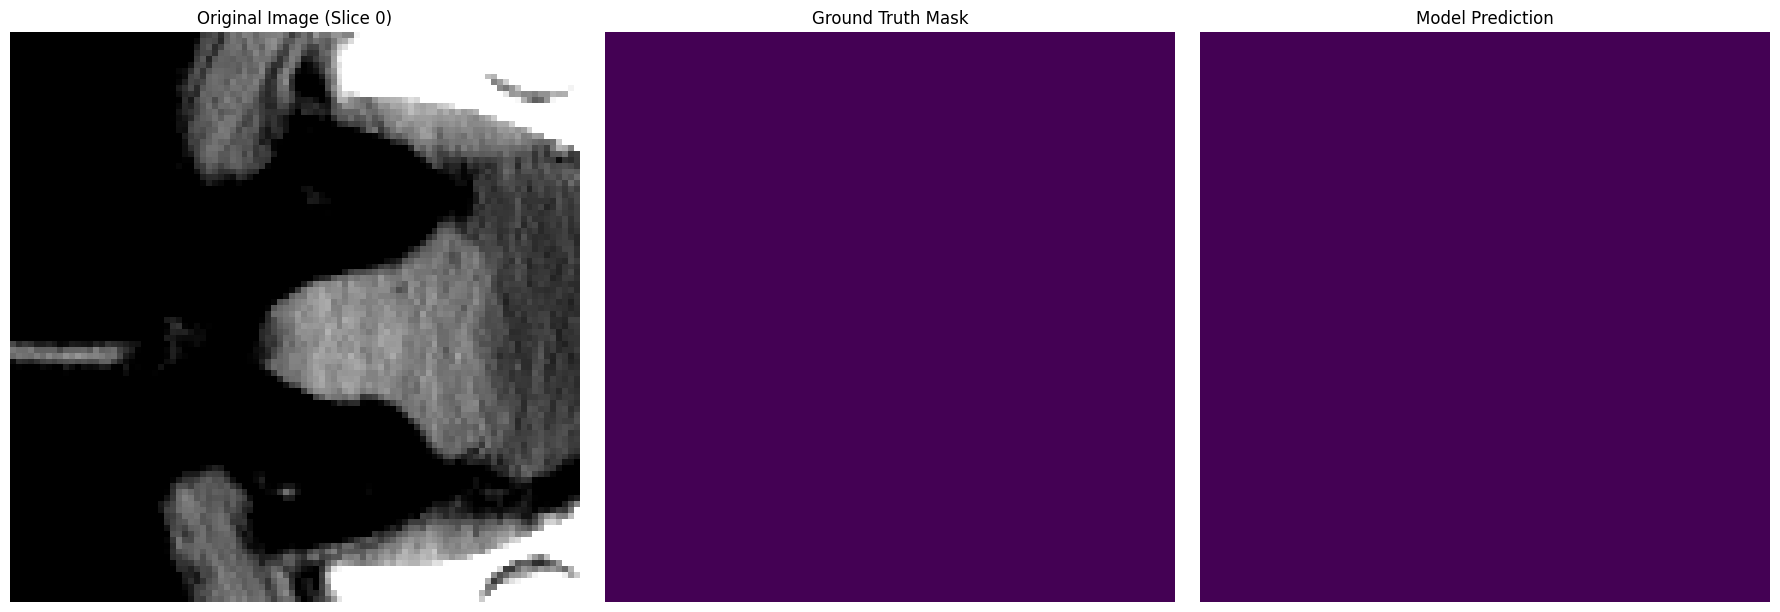

In [32]:
import torch
from monai.transforms import AsDiscrete

# Load the best saved model
model.load_state_dict(torch.load("best_metric_model.pth"))
model.eval()

# To convert model output to discrete binary mask
post_pred = AsDiscrete(argmax=True)
post_label = AsDiscrete(to_onehot=2)

with torch.no_grad():
    # Get a batch from the loader
    val_data = first(train_loader)
    val_inputs = val_data["image"].to(device)
    val_labels = val_data["label"].to(device)

    # Get prediction
    val_outputs = model(val_inputs)
    # Take the first image in the batch
    val_output_mask = post_pred(val_outputs[0]).cpu().numpy()[0] # Shape [H, W, D]
    val_true_mask = val_labels[0, 0].cpu().numpy() # Shape [H, W, D]
    val_img = val_inputs[0, 0].cpu().numpy()

# Find a slice that contains the spleen for visualization
slice_idx = np.argmax(np.sum(val_true_mask, axis=(0, 1)))

plt.figure("check", (18, 6))
plt.subplot(1, 3, 1)
plt.title(f"Original Image (Slice {slice_idx})")
plt.imshow(val_img[:, :, slice_idx], cmap="gray")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Ground Truth Mask")
plt.imshow(val_true_mask[:, :, slice_idx])
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Model Prediction")
plt.imshow(val_output_mask[:, :, slice_idx])
plt.axis('off')

plt.tight_layout()
plt.show()

### 7. Full-Volume Inference
We will now run the model on the full, uncropped image using a sliding window approach to visualize the segmentation across the entire scan.

Visualizing sample index: 9 - /tmp/tmposo76n38/Task09_Spleen/imagesTr/spleen_20.nii.gz


Loading dataset: 100%|██████████| 1/1 [00:05<00:00,  5.23s/it]


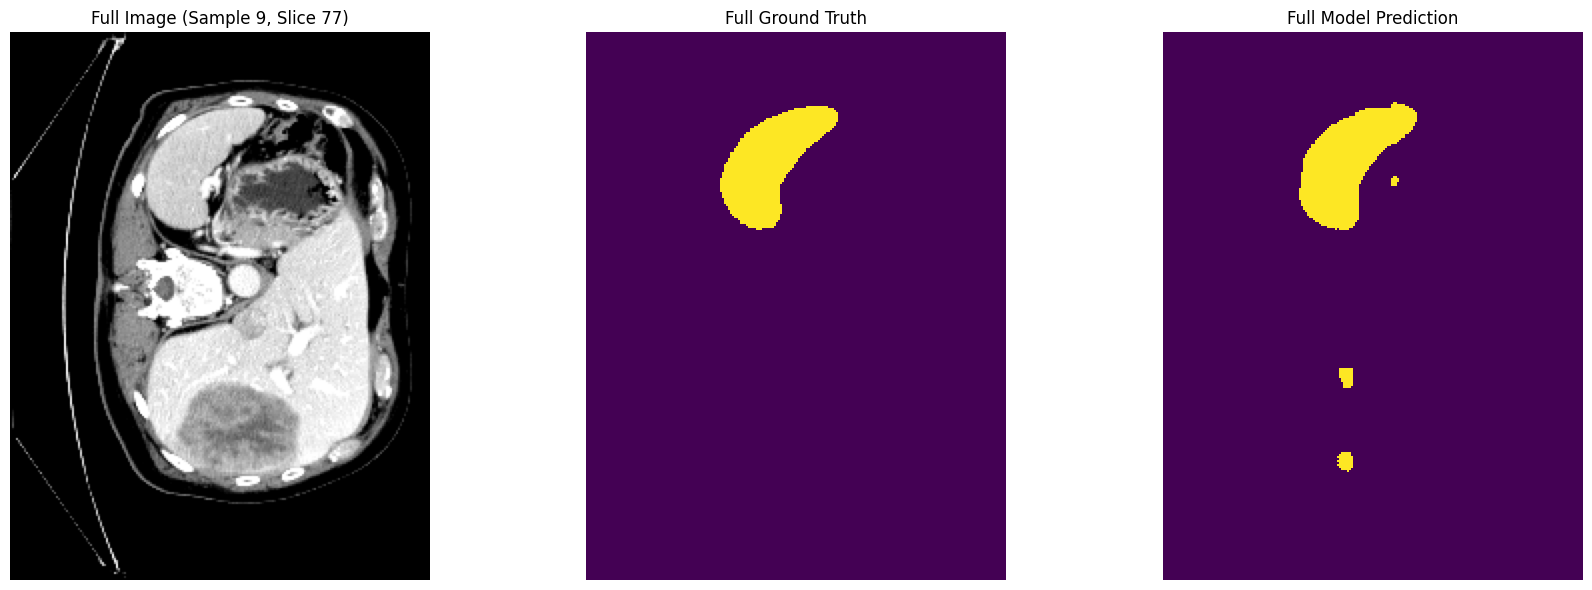

In [46]:
from monai.inferers import sliding_window_inference
import random

# Define the transforms for full-volume inference (no random cropping)
val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys=["image"], a_min=-57, a_max=164, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
])

# Select a random sample from the dataset
random_idx = random.randint(0, len(data_dicts) - 1)
print(f"Visualizing sample index: {random_idx} - {data_dicts[random_idx]['image']}")

# Pick the random volume
val_ds = CacheDataset(data=data_dicts[random_idx:random_idx+1], transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=1)

model.eval()
with torch.no_grad():
    for val_data in val_loader:
        val_inputs = val_data["image"].to(device)
        val_labels = val_data["label"].to(device)

        # ROI size must match what the model was trained on
        roi_size = (96, 96, 96)
        sw_batch_size = 4
        val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)

        # Convert to binary mask
        val_output_mask = torch.argmax(val_outputs, dim=1).detach().cpu()[0]
        val_image_full = val_inputs.cpu().numpy()[0, 0]
        val_label_full = val_labels.cpu().numpy()[0, 0]
        break

# Visualize a slice from the full volume (finding a slice with the label)
slice_idx = np.argmax(np.sum(val_label_full, axis=(0, 1)))

plt.figure("Full Volume Check", (18, 6))
plt.subplot(1, 3, 1)
plt.title(f"Full Image (Sample {random_idx}, Slice {slice_idx})")
plt.imshow(val_image_full[:, :, slice_idx], cmap="gray")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Full Ground Truth")
plt.imshow(val_label_full[:, :, slice_idx])
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Full Model Prediction")
plt.imshow(val_output_mask[:, :, slice_idx])
plt.axis('off')

plt.tight_layout()
plt.show()